In [3]:
import torch.nn as nn
import torch.nn.functional as F
import torch
import torchvision.transforms as transforms

import os 
from google.colab import files
from PIL import Image
import matplotlib.pyplot as plt
%matplotlib inline

Defining the model

In [4]:
def conv_block(in_channels, out_channels, pool=False):
    layers = [nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1), 
              nn.BatchNorm2d(out_channels), 
              nn.ReLU(inplace=True)]
    if pool: layers.append(nn.MaxPool2d(2))
    return nn.Sequential(*layers)

class ResNet9(nn.Module):
    def __init__(self, in_channels, num_classes):
        super().__init__()
        
        self.conv1 = conv_block(in_channels, 64)
        self.conv2 = conv_block(64, 128, pool=True)
        self.res1 = nn.Sequential(conv_block(128, 128), conv_block(128, 128))
        
        self.conv3 = conv_block(128, 256, pool=True)
        self.conv4 = conv_block(256, 512, pool=True)
        self.res2 = nn.Sequential(conv_block(512, 512), conv_block(512, 512))
        
        self.classifier = nn.Sequential(nn.AdaptiveMaxPool2d((1,1)), 
                                        nn.Flatten(), 
                                        nn.Dropout(0.2),
                                        nn.Linear(512, num_classes))
        
    def forward(self, xb):
        out = self.conv1(xb)
        out = self.conv2(out)
        out = self.res1(out) + out
        out = self.conv3(out)
        out = self.conv4(out)
        out = self.res2(out) + out
        out = self.classifier(out)
        return out

Making list of the classes

In [5]:
classes=['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

Choosing the device for the model

In [6]:
def get_default_device():
    """Pick GPU if available, else CPU"""
    if torch.cuda.is_available():
        return torch.device('cuda')
    else:
        return torch.device('cpu')
    
def to_device(data, device):
    """Move tensor(s) to chosen device"""
    if isinstance(data, (list,tuple)):
        return [to_device(x, device) for x in data]
    return data.to(device, non_blocking=True)

In [7]:
device=get_default_device()
print(device)

cpu


Loading the model

In [8]:
model = to_device(ResNet9(3,10), device)
model.load_state_dict(torch.load('/content/drive/MyDrive/Colab_Notebooks/personal_projects/resnet9/cifar10-resnet9.pth',map_location=torch.device(device)))

<All keys matched successfully>

In [9]:
stats = ((0.4914, 0.4822, 0.4465), (0.2471, 0.2436, 0.2617))
def predict_image(path, model):
    im=Image.open(path)
    # resizing images then converting image to tensor, normalizing the tensors
    transform = transforms.Compose([transforms.Resize((40,40)),transforms.ToTensor(),transforms.Normalize(*stats,inplace=True)]) 
    img=transform(im)
    # Convert to a batch of 1
    xb = to_device(img.unsqueeze(0), device)
    # Get predictions from model
    model.eval()
    with torch.no_grad():
        yb = model(xb)
    # Pick index with highest probability
    prob=nn.Softmax(dim=1)
    yb=prob(yb)
    _, preds  = torch.max(yb, dim=1)
    # Retrieve the class label
    print('Predicted:',classes[preds[0].item()],' with a probability of',str(round(torch.max(yb).item(), 4)*100)+'%')
    plt.imshow(im)
    plt.show()
     

Prediction of single images

Predicted: horse  with a probability of 100.0%


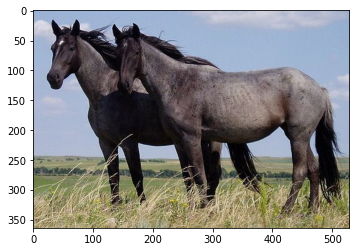

Predicted: cat  with a probability of 100.0%


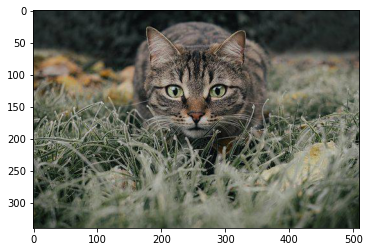

In [10]:

predict_image('/content/Nokota_Horses_cropped.jpg', model)
predict_image('/content/cat-5778777__340.jpg', model)

Prediction of images in a folder

Predicted: dog  with a probability of 99.05000000000001%


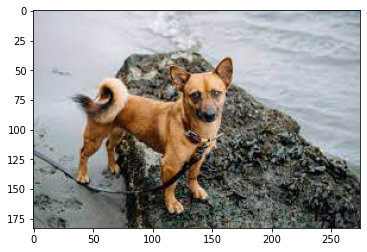

Predicted: ship  with a probability of 58.57%


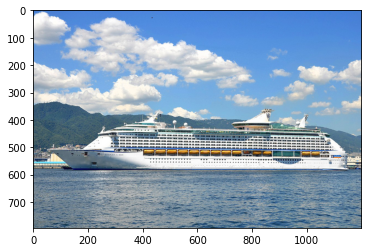

Predicted: deer  with a probability of 100.0%


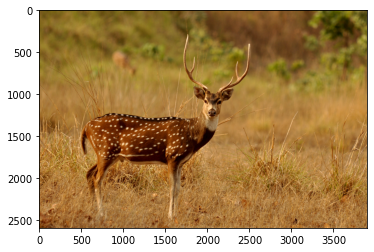

Predicted: cat  with a probability of 100.0%


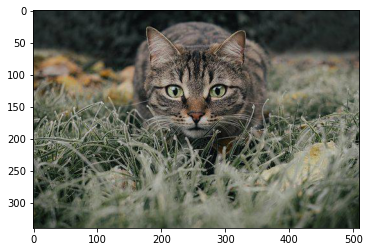

Predicted: horse  with a probability of 100.0%


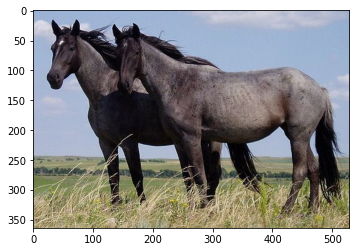

In [12]:
# enter the path of the folder containing the images
path = '/content/'

for file in os.listdir(path):
  if file.endswith('jpg') or file.endswith('png') or file.endswith('webp') or file.endswith('jpeg'):
    predict_image('/content/'+file, model)

Prediction after uploading of files to google collab

Saving dog3.jpg to dog3 (1).jpg
Saving GettyImages-185298837.webp to GettyImages-185298837.webp
Saving golder-retriever-puppy.jpeg to golder-retriever-puppy.jpeg
Saving horse-3.jpg to horse-3.jpg
Saving horses.jpg to horses.jpg
Saving Male-white-tailed-deer.webp to Male-white-tailed-deer.webp
Saving Nokota_Horses_cropped.jpg to Nokota_Horses_cropped (1).jpg
Saving sonet-exterior-right-rear-three-quarter.jpeg to sonet-exterior-right-rear-three-quarter.jpeg
Saving Voyager_of_the_Seas_at_Port_of_Kobe.jpg to Voyager_of_the_Seas_at_Port_of_Kobe (1).jpg
Saving ZX7JMN3A4ZKDNMZ2A6PL3FFJTM.jpg to ZX7JMN3A4ZKDNMZ2A6PL3FFJTM.jpg
Predicted: dog  with a probability of 99.05000000000001%


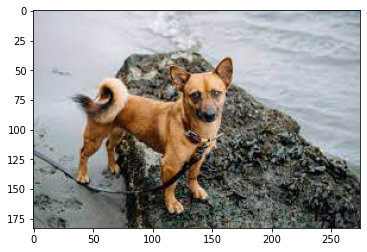

Predicted: airplane  with a probability of 99.99%


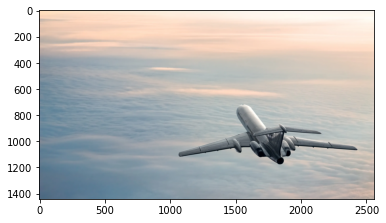

Predicted: dog  with a probability of 100.0%


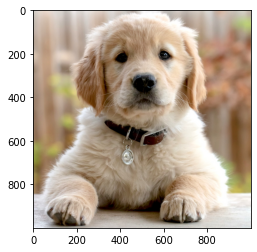

Predicted: horse  with a probability of 99.41%


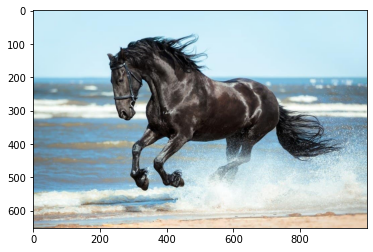

Predicted: horse  with a probability of 100.0%


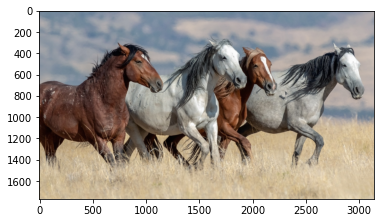

Predicted: deer  with a probability of 100.0%


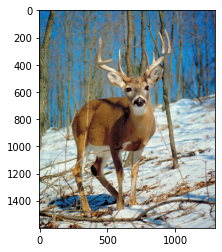

Predicted: horse  with a probability of 100.0%


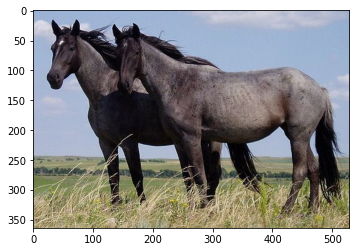

Predicted: automobile  with a probability of 99.26%


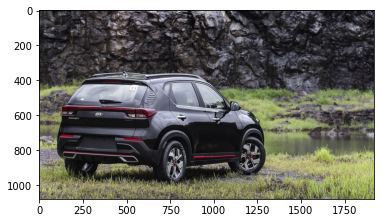

Predicted: ship  with a probability of 58.57%


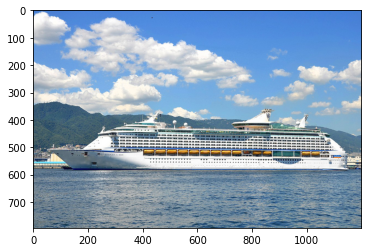

Predicted: deer  with a probability of 99.99%


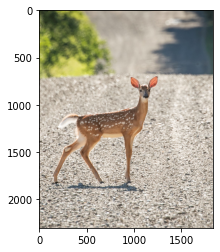

In [13]:
uploaded = files.upload()

for fn in uploaded.keys():
  predict_image('/content/'+fn, model)


Saving 7A715AD8-449D-4B5A-ABA2C5D92D9B5A21_source.webp to 7A715AD8-449D-4B5A-ABA2C5D92D9B5A21_source.webp
Saving 800px-Cyanocitta_cristata_FWS_(uncropped).jpg to 800px-Cyanocitta_cristata_FWS_(uncropped).jpg
Saving 1200.jpg to 1200.jpg
Saving 1200x-1.jpg to 1200x-1.jpg
Saving 180130_White-tailed deer_lg.webp to 180130_White-tailed deer_lg.webp
Saving 200601-ecaravan-magnix-ew-451p.jpg to 200601-ecaravan-magnix-ew-451p.jpg
Saving A_chital_stag_1.jpg to A_chital_stag_1 (1).jpg
Saving cat2.jpg to cat2.jpg
Saving cat-5778777__340.jpg to cat-5778777__340 (1).jpg
Saving catbird.webp to catbird.webp
Predicted: bird  with a probability of 100.0%


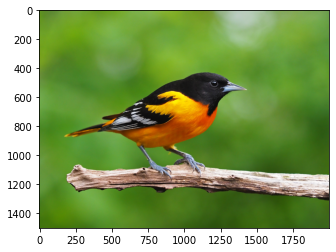

Predicted: bird  with a probability of 97.22%


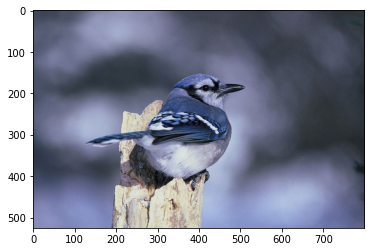

Predicted: bird  with a probability of 100.0%


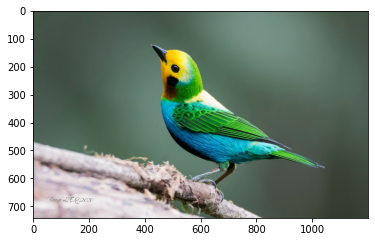

Predicted: airplane  with a probability of 100.0%


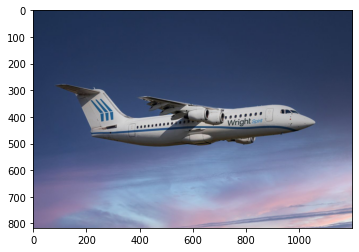

Predicted: deer  with a probability of 99.96000000000001%


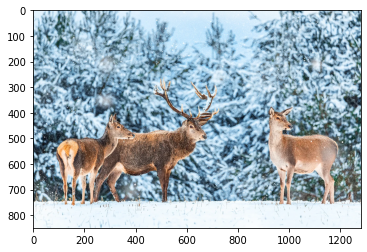

Predicted: airplane  with a probability of 100.0%


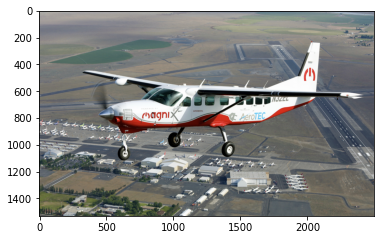

Predicted: deer  with a probability of 100.0%


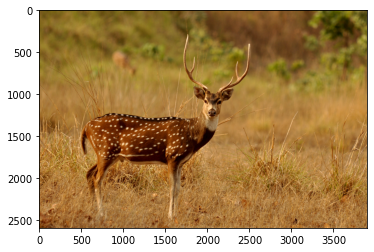

Predicted: cat  with a probability of 100.0%


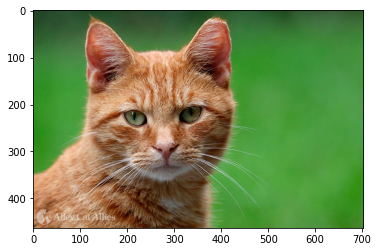

Predicted: cat  with a probability of 100.0%


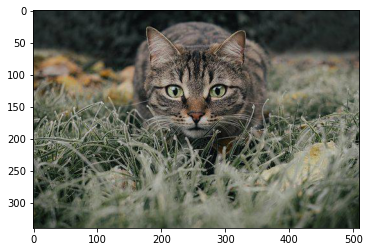

Predicted: cat  with a probability of 96.55%


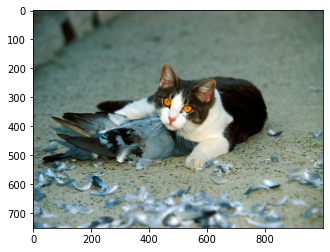

In [14]:
uploaded = files.upload()

for fn in uploaded.keys():
  predict_image('/content/'+fn, model)